In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    df = pd.read_csv("store.csv")
except FileExistsError:
    print("this file doesn't exist")

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df.shape

(9800, 18)

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [11]:
df = df.drop_duplicates()

In [12]:
df['postal_code'] = df['postal_code'].fillna(0).astype(int)

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'],errors="coerce")
df['ship_date'] = pd.to_datetime(df['ship_date'], errors="coerce")

In [14]:
categorical_cols = [
    'ship_mode','segment','country','city','state',
    'region','category','sub-category'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [15]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter

In [16]:
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

In [17]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'year', 'month', 'quarter', 'delivery_days'],
      dtype='str')

<Axes: title={'center': 'Top 10 Products'}, ylabel='product_name'>

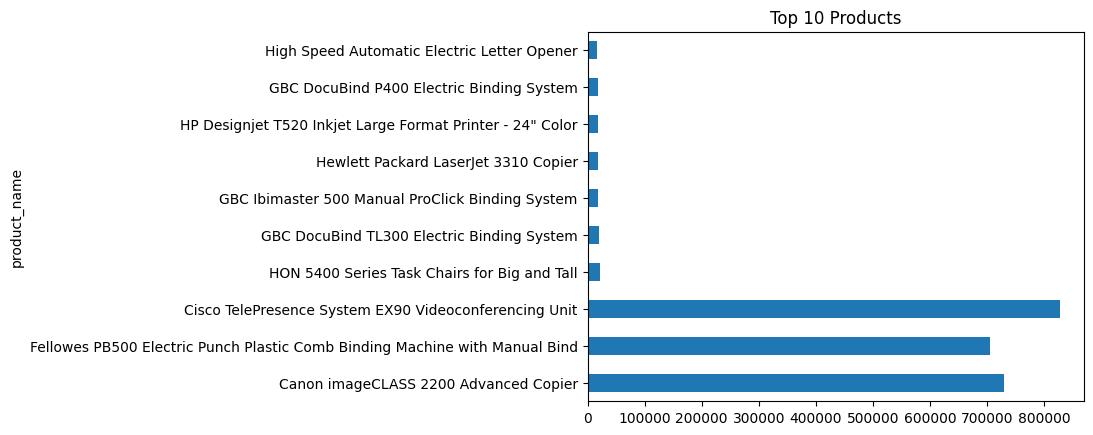

In [18]:
total_sales = df['sales'].sum()

sales_by_category = df.groupby('category')['sales'].sum()
sales_by_category.plot(kind='barh', title='Sales by Category')

top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', title='Top 10 Products')

In [19]:
q1 = df['sales'].quantile(0.25)
q3 = df['sales'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]
print("Outliers:", len(outliers))

Outliers: 1145


In [20]:
total_sales = df['sales'].sum()
print("Total Revenue:", total_sales)

Total Revenue: 2261536.7827


Text(0.5, 1.0, 'Sales by Category')

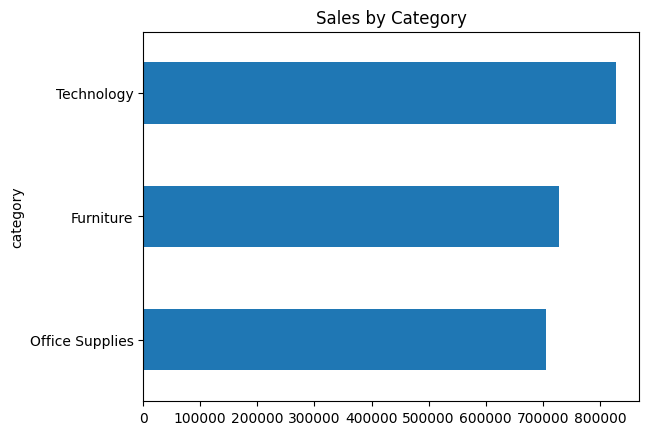

In [21]:
sales_by_category = df.groupby('category')['sales'].sum().sort_values()

sales_by_category.plot(kind='barh')
plt.title("Sales by Category")

Text(0.5, 1.0, 'Sales by Region')

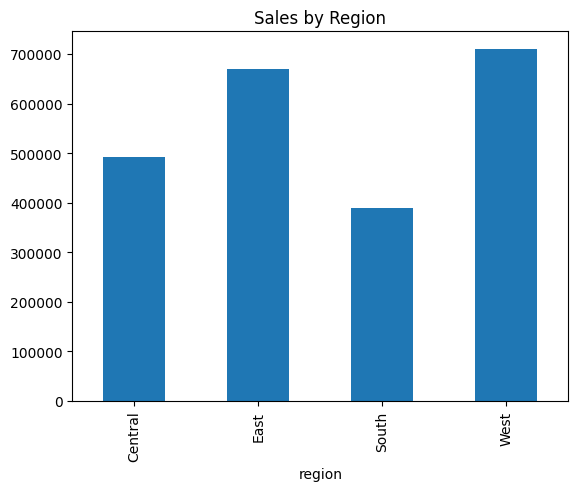

In [22]:
sales_by_region = df.groupby('region')['sales'].sum()

sales_by_region.plot(kind='bar')
plt.title("Sales by Region")

Text(0.5, 1.0, 'Top 10 Products')

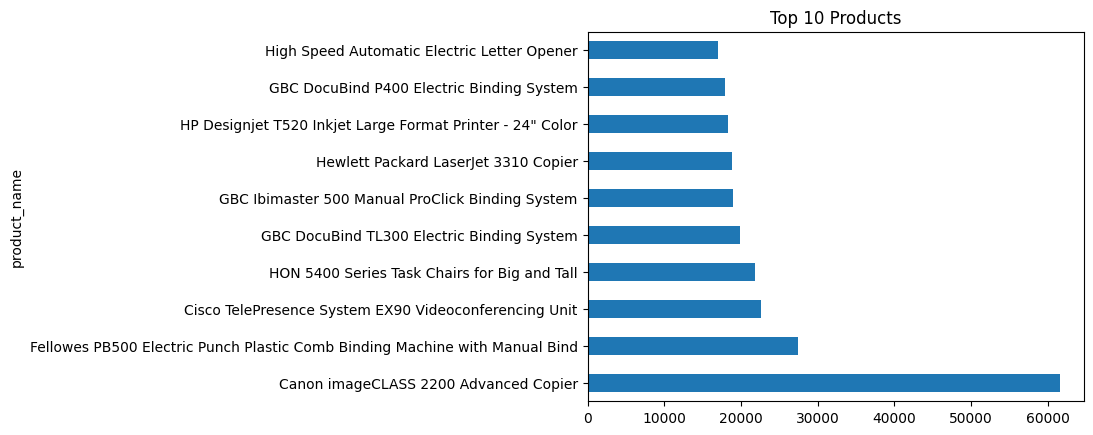

In [23]:
top_products = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='barh')
plt.title("Top 10 Products")

Text(0.5, 1.0, 'Monthly Sales Trend')

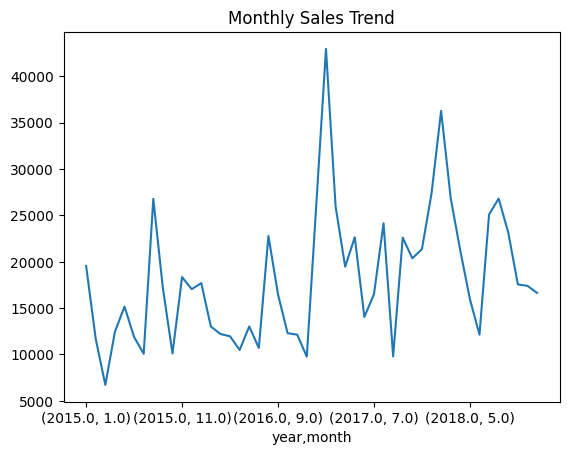

In [24]:
monthly_sales = df.groupby(['year','month'])['sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")

In [26]:
from io import StringIO

buffer = StringIO()
df.to_csv(buffer, index=False)
csv_string = buffer.getvalue()
print(csv_string)

row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,year,month,quarter,delivery_days
1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017.0,8.0,3.0,92.0
2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.94,2017.0,8.0,3.0,92.0
3,CA-2017-138688,2017-12-06,,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.62,2017.0,12.0,4.0,
4,US-2016-108966,2016-11-10,,Standard Class,SO-20335,Sean O'Donnell,Consumer,U

In [39]:
df.to_csv(r'C:\Users\user\Desktop\report.csv', index=False)